In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.eda_utils import (
    set_aesthetics,
    load_data,
    assess_quality,
    plot_class_distribution,
    plot_correlation_heatmap
)

# ── Aesthetics ──
FRAUD_PAL = {0: "#4C72B0", 1: "#DD4444", "0": "#4C72B0", "1": "#DD4444"}   # blue = normal, red = fraud
SEED = 42
set_aesthetics(palette_style="muted", font_scale=1.1)

Libraries loaded & global aesthetics set ✓


In [9]:
# Load and Inspect datasets
fraud_df_raw = load_data('../data/raw/Fraud_Data.csv')
ip_df_raw = load_data('../data/raw/IpAddress_to_Country.csv')

print("\nFraud Data sample:")
display(fraud_df_raw.head(3))
print("\nIP mapping table sample:")
display(ip_df_raw.head(3))

Loading data from: ../data/raw/Fraud_Data.csv
Shape  : 151,112 rows × 11 columns
Memory : 59.7 MB
Loading data from: ../data/raw/IpAddress_to_Country.csv
Shape  : 138,846 rows × 3 columns
Memory : 10.5 MB

Fraud Data sample:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368.7997,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387.8659,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820.1109,1



IP mapping table sample:


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0000,16777471,Australia
1,16777472.0000,16777727,China
2,16777728.0000,16778239,China


In [10]:
# Data quality check
print("Checking Fraud Dataset quality:")
quality_report_fraud, n_dup_fraud = assess_quality(fraud_df_raw)

print("\nChecking IP Mapping Dataset quality:")
quality_report_ip, n_dup_ip = assess_quality(ip_df_raw)

Checking Fraud Dataset quality:
No missing values detected.

Duplicate rows : 0

Checking IP Mapping Dataset quality:
No missing values detected.

Duplicate rows : 0


In [11]:
fraud_df = fraud_df_raw.copy()

# Step 1: Drop index col if present
if 'Unnamed: 0' in fraud_df.columns:
    fraud_df = fraud_df.drop(columns=['Unnamed: 0'])
    print("Dropped Unnamed: 0 index column.")

# Step 2: Convert datetimes
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])
print("Converted signup_time and purchase_time to datetime.")



fraud_df.head(3)

Converted signup_time and purchase_time to datetime.


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368.7997,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387.8659,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820.1109,1


In [ ]:
fraud_df.to_csv("../data/processed/Fraud_Cleaned_Data.csv", index=False)
ip_df_raw.to_csv("../data/processed/IPAddress_Cleaned_Data.csv", index=False)

,count,percent_%
Normal (0),136961,90.6354
Fraud (1),14151,9.3646



Imbalance ratio (Normal : Fraud) = 10 : 1
Saved class distribution plot to: ../notebooks/ecommerce_class_dist.png


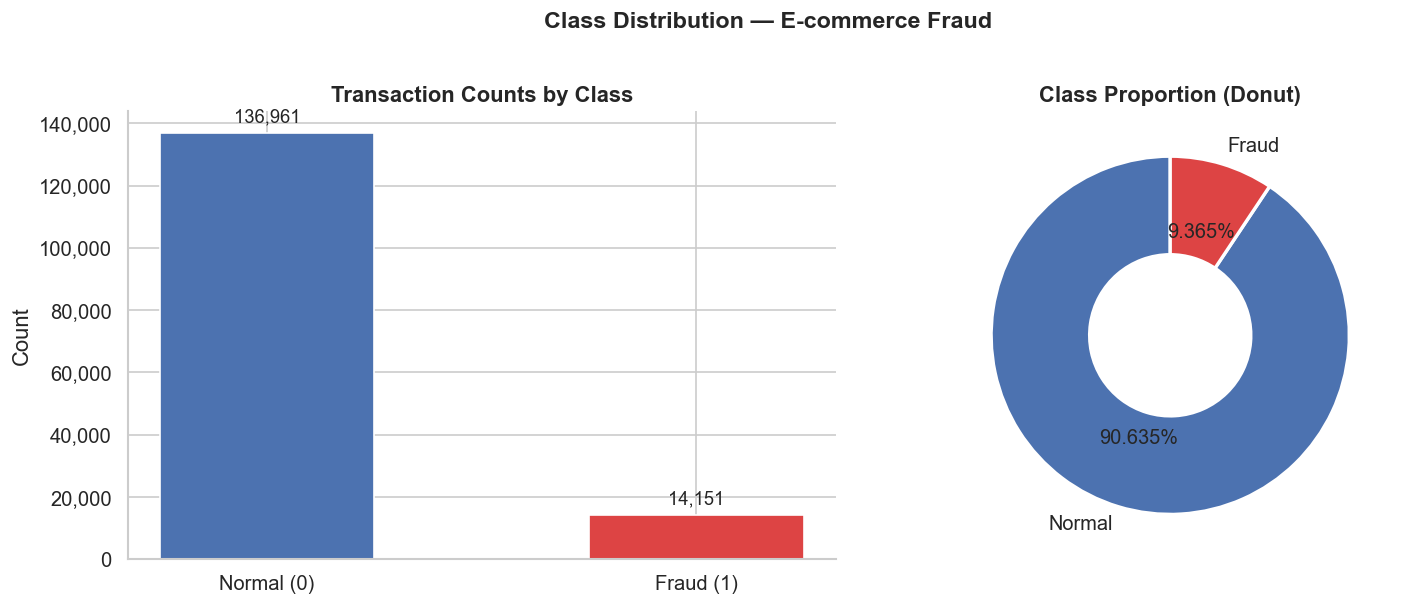

In [ ]:
# Class distribution and imbalance
plot_class_distribution(fraud_df, "class", "Class Distribution — E-commerce Fraud", palette=FRAUD_PAL, save_path="../notebooks/ecommerce_class_dist.png")

In [27]:
fraud_df_cleaned=pd.read_csv('../data/processed/Fraud_Cleaned_Data.csv')
ip_df_cleaned=pd.read_csv('../data/processed/IPAddress_Cleaned_Data.csv')

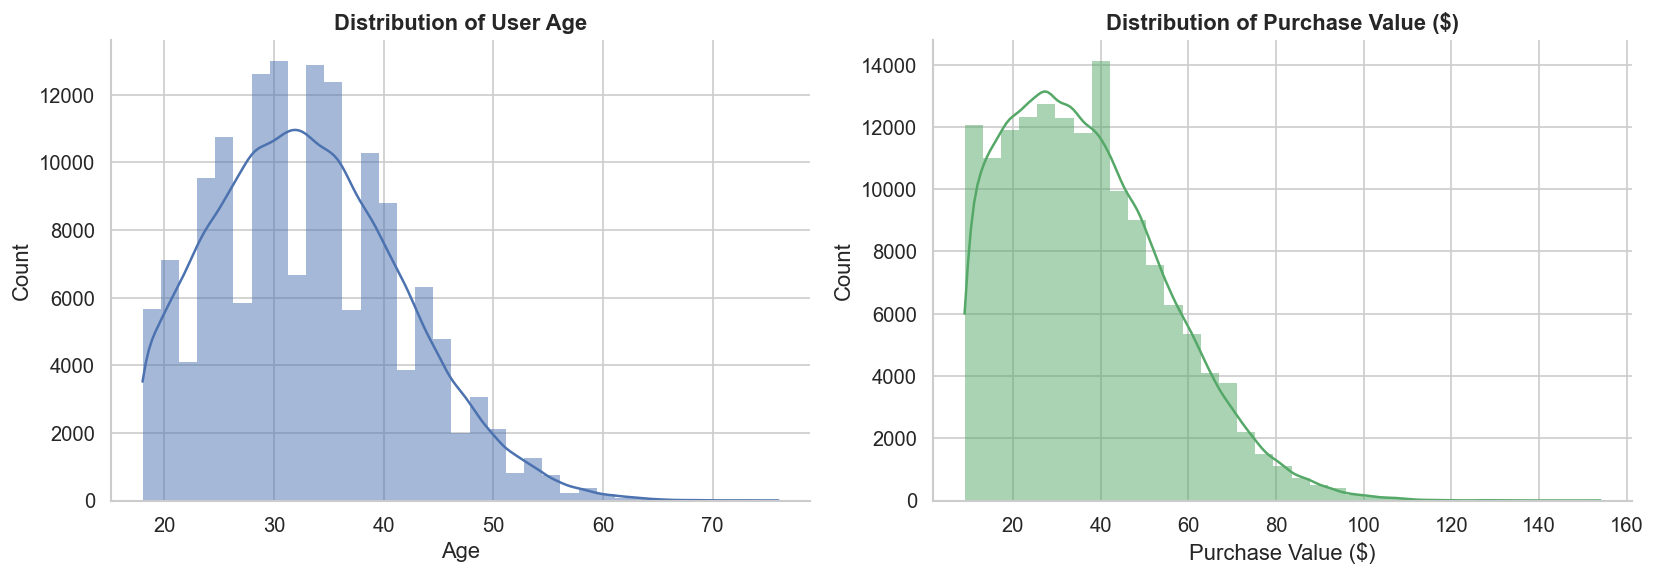

Numerical features statistical summary:


,count,mean,std,min,25%,50%,75%,max
age,151112.0000,33.1407,8.6177,18.0000,27.0000,33.0000,39.0000,76.0000
purchase_value,151112.0000,36.9354,18.3228,9.0000,22.0000,35.0000,49.0000,154.0000


In [29]:
# Univariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
sns.histplot(fraud_df_cleaned, x='age', bins=35, kde=True, ax=axes[0], color="#4C72B0", edgecolor="none")
axes[0].set_title('Distribution of User Age', fontweight="bold")
axes[0].set_xlabel('Age')

# Purchase Value distribution
sns.histplot(fraud_df_cleaned, x='purchase_value', bins=35, kde=True, ax=axes[1], color="#55A868", edgecolor="none")
axes[1].set_title('Distribution of Purchase Value ($)', fontweight="bold")
axes[1].set_xlabel('Purchase Value ($)')

plt.tight_layout()
plt.show()

print("Numerical features statistical summary:")
display(fraud_df_cleaned[['age', 'purchase_value']].describe().T)

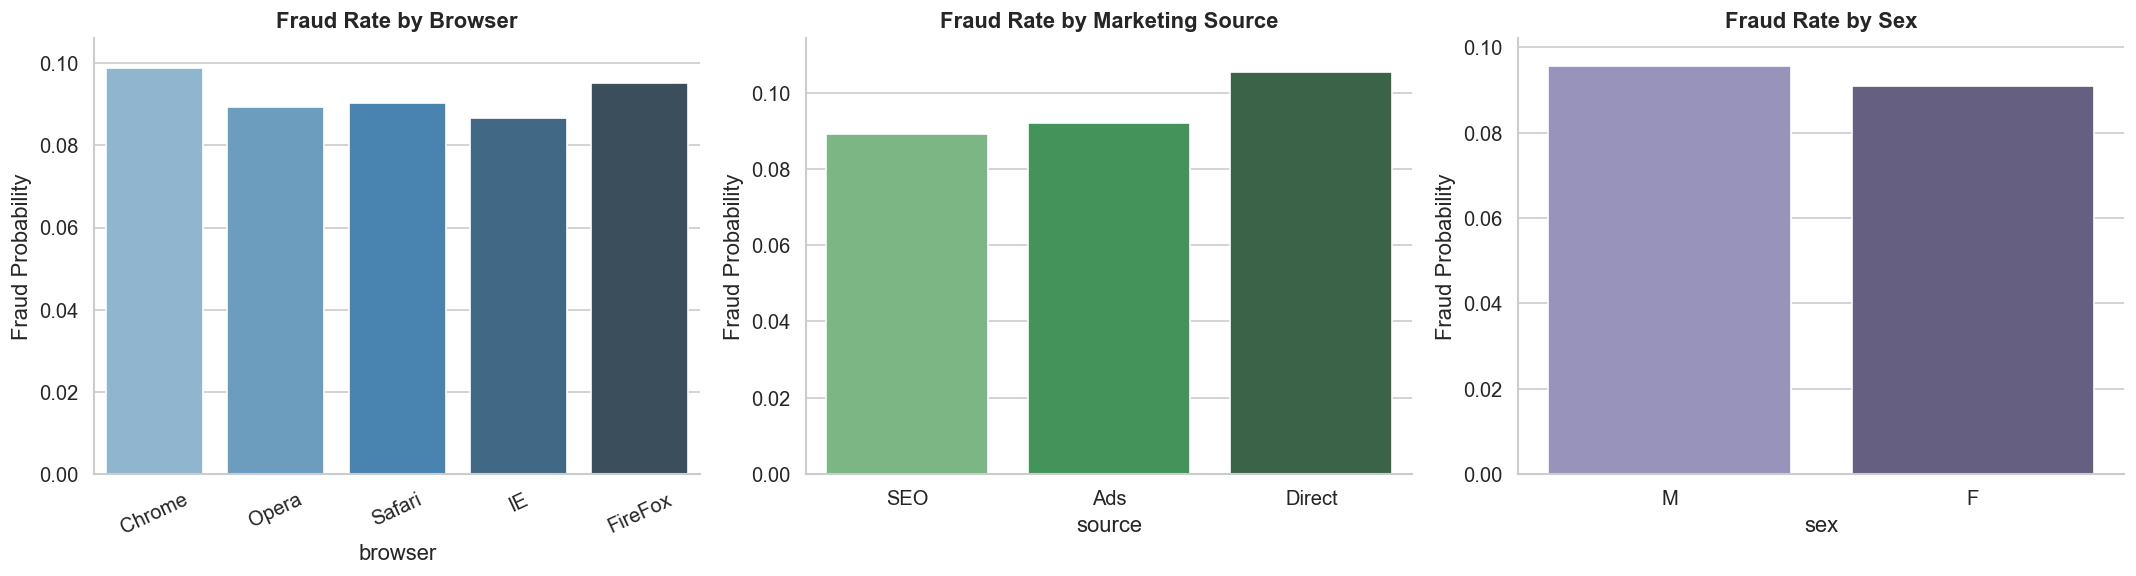

In [30]:
# Bivariate Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Browser vs Fraud Rate
sns.barplot(x='browser', y='class', data=fraud_df_cleaned, ax=axes[0], palette="Blues_d", errwidth=0)
axes[0].set_title('Fraud Rate by Browser', fontweight="bold")
axes[0].set_ylabel('Fraud Probability')
axes[0].tick_params(axis='x', rotation=25)

# Source vs Fraud Rate
sns.barplot(x='source', y='class', data=fraud_df_cleaned, ax=axes[1], palette="Greens_d", errwidth=0)
axes[1].set_title('Fraud Rate by Marketing Source', fontweight="bold")
axes[1].set_ylabel('Fraud Probability')

# Sex vs Fraud Rate
sns.barplot(x='sex', y='class', data=fraud_df_cleaned, ax=axes[2], palette="Purples_d", errwidth=0)
axes[2].set_title('Fraud Rate by Sex', fontweight="bold")
axes[2].set_ylabel('Fraud Probability')

plt.tight_layout()
plt.show()

In [31]:
fraud_df_cleaned.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368.7997,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387.8659,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820.1109,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3840542443.9140,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,415583117.4527,0


In [32]:
ip_df_cleaned.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0000,16777471,Australia
1,16777472.0000,16777727,China
2,16777728.0000,16778239,China
3,16778240.0000,16779263,Australia
4,16779264.0000,16781311,China


In [33]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.geolocation import prepare_ip_df_bounds, map_ip_to_country

fraud_df['ip_int'] = fraud_df['ip_address'].astype('int64')

In [34]:
# Ensure IP range boundaries are integers and prepare ip_df
ip_df_cleaned = prepare_ip_df_bounds(ip_df_cleaned)

In [35]:
# Map ip integers to countries using the vectorized helper
fraud_df_cleaned = map_ip_to_country(fraud_df_cleaned, ip_df_cleaned, ip_int_col='ip_int', country_col='country')

In [36]:
# merge the datasets

# Find matching range
idx = ip_df_cleaned["lower_bound_ip_address"].searchsorted(
    fraud_df_cleaned["ip_address"],
    side="right"
) - 1

# Attach candidate rows
fraud_df_cleaned["range_idx"] = idx

merged_df = fraud_df_cleaned.merge(
    ip_df_cleaned.reset_index().rename(columns={"index": "range_idx"}),
    on="range_idx",
    how="left"
)

# Keep only valid matches
merged_df = merged_df[
    merged_df["ip_address"] <= merged_df["upper_bound_ip_address"]
]

# Optional cleanup
merged_df = merged_df.drop(columns=["range_idx"])

print(merged_df.head())

   user_id          signup_time        purchase_time  purchase_value  \
0    22058  2015-02-24 22:55:49  2015-04-18 02:47:11              34   
1   333320  2015-06-07 20:39:50  2015-06-08 01:38:54              16   
2     1359  2015-01-01 18:52:44  2015-01-01 18:52:45              15   
4   221365  2015-07-21 07:09:52  2015-09-09 18:40:53              39   
5   159135  2015-05-21 06:03:03  2015-07-09 08:05:14              42   

       device_id source browser sex  age      ip_address  class      ip_int  \
0  QVPSPJUOCKZAR    SEO  Chrome   M   39  732758368.7997      0   732758368   
1  EOGFQPIZPYXFZ    Ads  Chrome   F   53  350311387.8659      0   350311387   
2  YSSKYOSJHPPLJ    SEO   Opera   M   53 2621473820.1109      1  2621473820   
4  NAUITBZFJKHWW    Ads  Safari   M   45  415583117.4527      0   415583117   
5  ALEYXFXINSXLZ    Ads  Chrome   M   18 2809315199.9268      0  2809315199   

       country_x  lower_bound_ip_address  upper_bound_ip_address  \
0          Japan        

In [ ]:
# Compute fraud rate per country
fraud_rate = fraud_df_cleaned.groupby('country')['class'].mean().sort_values(ascending=False)
fraud_rate.head(10)

country
Turkmenistan            1.0000
Namibia                 0.4348
Sri Lanka               0.4194
Luxembourg              0.3889
Virgin Islands (U.S.)   0.3333
Ecuador                 0.2642
Tunisia                 0.2627
Peru                    0.2605
Bolivia                 0.2453
Kuwait                  0.2333
Name: class, dtype: float64